# 03 — Multi-Objective AI Assistant

## Goal

Make the classifier actually useful for business ops. For each review output:
1. **Stars** (1-5)
2. **Key signal** — the single most salient complaint or compliment (type + short text)
3. **Business response** — polite, professional, ideally proposes a concrete next step

## Evaluation protocol

- Stars use ground truth from Yelp.
- Signal + response have no ground truth → **LLM-as-judge** using a **different family** (`anthropic/claude-haiku-4.5`) to avoid self-judge bias.
- Judge scores 3 axes 1-5: faithfulness, politeness, actionability.

## Setup

- Classifier: `deepseek/deepseek-v3.2` (winner from notebook 01)
- Judge: `anthropic/claude-haiku-4.5`
- 150 stratified Yelp reviews for classifier; 60 random subset for judge (cost control).

In [1]:
import sys; sys.path.insert(0, '..')
import json, time, random
from collections import defaultdict
from pathlib import Path
import pandas as pd

from lib.config import ACTIVE_CLASSIFIER, JUDGE
from lib.gateway import classify_json
from lib.schemas import MultiObjective, JudgeScore
from lib.prompts import ASSISTANT_SYSTEM, JUDGE_SYSTEM, assistant, judge as judge_prompt
from lib.datasets import read_jsonl
from lib.concurrency import gather_limited
from lib.metrics import Prediction, report, fmt

CLASSES = [1, 2, 3, 4, 5]
N_PER_CLASS = 30
N_CLASSIFIER = N_PER_CLASS * len(CLASSES)  # 150
N_JUDGE = 60

_full = read_jsonl('../data/yelp_eval.jsonl')
_by_class = defaultdict(list)
for _r in _full:
    _by_class[_r['stars']].append(_r)
_rng = random.Random(42)
eval_set = []
for _s in CLASSES:
    eval_set.extend(_rng.sample(_by_class[_s], N_PER_CLASS))
_rng.shuffle(eval_set)

from collections import Counter
print(f'classifier: {ACTIVE_CLASSIFIER}')
print(f'judge:      {JUDGE}')
print(f'n eval:     {len(eval_set)}')
print(f'dist:       {dict(sorted(Counter(r["stars"] for r in eval_set).items()))}')

classifier: deepseek/deepseek-v3.2
judge:      anthropic/claude-haiku-4.5
n eval:     150
dist:       {1: 30, 2: 30, 3: 30, 4: 30, 5: 30}


## Run classifier — full multi-objective output

In [2]:
async def run_assistant(row):
    obj, meta = await classify_json(MultiObjective, ASSISTANT_SYSTEM, assistant(row['text']))
    if obj is None:
        return {'pred': None, 'truth': row['stars'], 'text': row['text'], 'err': meta.get('error')}
    return {
        'pred': obj.stars,
        'truth': row['stars'],
        'signal_type': obj.signal.type,
        'signal_text': obj.signal.text,
        'response': obj.business_response,
        'text': row['text'],
    }

t0 = time.time()
outputs = await gather_limited(eval_set, run_assistant, 30, 'assistant')
print(f'\ntime: {time.time()-t0:.1f}s')
preds = [Prediction(pred=o['pred'], truth=o['truth']) for o in outputs]
r = report(preds, CLASSES)
print(fmt(r))

assistant:   0%|          | 0/150 [00:00<?, ?it/s]

assistant:   1%|          | 1/150 [00:00<00:22,  6.59it/s]

assistant:  11%|█▏        | 17/150 [00:04<00:37,  3.50it/s]

assistant:  13%|█▎        | 19/150 [00:05<00:36,  3.61it/s]

assistant:  14%|█▍        | 21/150 [00:05<00:32,  3.92it/s]

...

assistant:  97%|█████████▋| 146/150 [00:26<00:00,  4.77it/s]

assistant:  99%|█████████▊| 148/150 [00:26<00:00,  6.23it/s]

assistant:  99%|█████████▉| 149/150 [00:26<00:00,  6.50it/s]

assistant: 100%|██████████| 150/150 [00:26<00:00,  5.57it/s]


time: 26.9s
n=150  compliance=100.0%  accuracy=66.0%  macroF1=0.654  MAE=0.347
confusion (rows=truth, cols=pred):
    22    8    0    0    0
     2   23    4    1    0
     0    6   17    7    0
     0    0    2   11   17
     0    0    0    4   26


## Sample outputs

Show 3 rows: one likely easy, one mid, one negative.

In [3]:
for picked in [[o for o in outputs if o.get('truth') == s and o.get('pred') is not None][0] for s in [5, 3, 1]]:
    print(f"truth={picked['truth']}★ pred={picked['pred']}★")
    print(f"  signal ({picked['signal_type']}): {picked['signal_text']}")
    print(f"  response: {picked['response'][:300]}")
    print()

truth=5★ pred=5★
  signal (compliment): Compliment on genuine care and proactive follow-up: 'They are super friendly and genuinely care about your animals! ... they called to check in with me and see how everything was going.'
  response: Thank you so much for your wonderful review and for trusting us with both Lexi and Hula. We're delighted to hear that our team's friendliness and proactive follow-up made a positive difference, and we're especially glad we could help diagnose and manage Hula's thyroid condition. It's our pleasure to

truth=3★ pred=2★
  signal (complaint): Payment friction: Customer experienced an 'awkward moment' when attempting to purchase but not having an Amex card, leading them to leave and buy elsewhere.
  response: Thank you for your feedback. We sincerely apologize for the awkward experience at checkout regarding our payment options. We are reviewing our accepted payment methods to better serve all our customers. In the meantime, we'd like to offer you a 15% di

## Judge scoring — cross-family (Haiku 4.5 on DeepSeek output)

In [4]:
to_judge = [o for o in outputs if o.get('pred') is not None and o.get('response')][:N_JUDGE]
print(f'judging {len(to_judge)} samples...')

async def run_judge(o):
    p = judge_prompt(
        review=o['text'],
        stars=o['pred'],
        signal_type=o['signal_type'],
        signal_text=o['signal_text'],
        response=o['response'],
    )
    score, meta = await classify_json(JudgeScore, JUDGE_SYSTEM, p, model=JUDGE)
    return score.model_dump() if score else None

t0 = time.time()
judge_scores = await gather_limited(to_judge, run_judge, 15, 'judge')
print(f'time: {time.time()-t0:.1f}s')
valid = [s for s in judge_scores if s is not None]
print(f'valid judge responses: {len(valid)} / {len(judge_scores)}')

judging 60 samples...


judge:   0%|          | 0/60 [00:00<?, ?it/s]

judge:   5%|▌         | 3/60 [00:01<00:31,  1.80it/s]

judge:   8%|▊         | 5/60 [00:01<00:18,  2.94it/s]

judge:  12%|█▏        | 7/60 [00:02<00:12,  4.34it/s]

...

judge:  92%|█████████▏| 55/60 [00:08<00:00,  7.47it/s]

judge:  95%|█████████▌| 57/60 [00:08<00:00,  8.83it/s]

judge:  98%|█████████▊| 59/60 [00:08<00:00,  7.89it/s]

judge: 100%|██████████| 60/60 [00:08<00:00,  6.96it/s]

time: 8.6s
valid judge responses: 49 / 60


In [5]:
jdf = pd.DataFrame(valid)[['faithfulness', 'politeness', 'actionability']]
summary = jdf.agg(['mean', 'std', 'min', 'max']).round(2)
print('judge aggregate scores (1-5):')
summary

judge aggregate scores (1-5):


,faithfulness,politeness,actionability
mean,4.00,4.98,3.06
std,0.89,0.14,1.03
min,1.00,4.00,2.00
max,5.00,5.00,5.00


## Distribution of judge scores

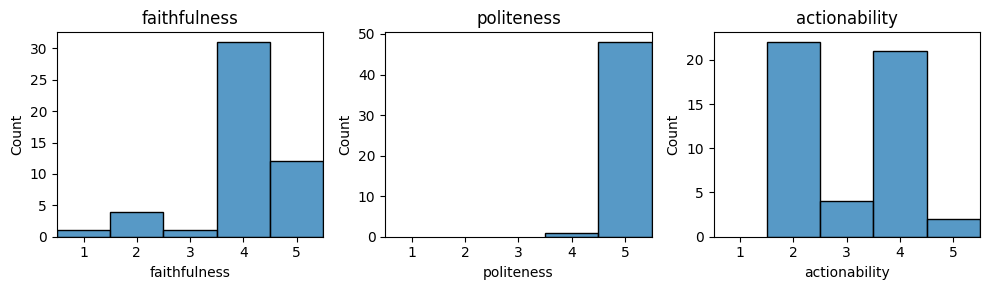

In [6]:
import matplotlib.pyplot as plt, seaborn as sns
Path('../results/plots').mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, col in zip(axes, ['faithfulness', 'politeness', 'actionability']):
    sns.histplot(jdf[col], bins=5, ax=ax, discrete=True)
    ax.set_title(col); ax.set_xlim(0.5, 5.5)
plt.tight_layout(); plt.savefig('../results/plots/03_judge_dist.png', dpi=120); plt.show()

## Worst cases per axis

In [7]:
paired = list(zip(to_judge, judge_scores))
for axis in ['faithfulness', 'politeness', 'actionability']:
    scored = [(s[axis], o) for o, s in paired if s is not None]
    scored.sort(key=lambda x: x[0])
    print(f'\n--- lowest {axis} ---')
    for score, o in scored[:2]:
        print(f'  score={score} truth={o["truth"]}★ pred={o["pred"]}★')
        print(f'    signal: {o["signal_text"][:120]}')
        print(f'    response: {o["response"][:180]}')


--- lowest faithfulness ---
  score=1 truth=2★ pred=2★
    signal: A bartender was unnecessarily rude and implied I was going to leave without paying by standing next to me the whole time
    response: Thank you for your detailed feedback and for being a long-time patron. We sincerely apologize for the disrespectful experience you had with our bartender on St. Patrick's Day in 20
  score=2 truth=4★ pred=5★
    signal: The reviewer was highly impressed by the quality and creativity of the vegan food, specifically praising the Squash Blos
    response: Thank you so much for your wonderful review! We're delighted to hear you were impressed with your visit and that you enjoyed the Squash Blossom Hush Puppies so much. It's great to 

--- lowest politeness ---
  score=4 truth=2★ pred=2★
    signal: A bartender was unnecessarily rude and implied I was going to leave without paying by standing next to me the whole time
    response: Thank you for your detailed feedback and for being a long-ti

In [8]:
out = {
    'classifier': ACTIVE_CLASSIFIER,
    'judge': JUDGE,
    'classification': r,
    'judge_aggregate': {c: {'mean': float(jdf[c].mean()), 'std': float(jdf[c].std())} for c in ['faithfulness','politeness','actionability']},
    'n_classifier': len(outputs),
    'n_judge': len(valid),
    'samples': [
        {'truth': o['truth'], 'pred': o.get('pred'), 'signal_type': o.get('signal_type'),
         'signal_text': o.get('signal_text'), 'response': o.get('response'),
         'judge': s}
        for o, s in paired[:5]
    ],
}
Path('../results').mkdir(exist_ok=True)
Path('../results/03_multi_objective.json').write_text(json.dumps(out, indent=2))
print('wrote results/03_multi_objective.json')

wrote results/03_multi_objective.json


## Findings (fill in after run)

- Star accuracy vs notebook 01 baseline — does multi-objective prompt hurt classification?
- Judge scores — which axis is weakest? (usually actionability.)
- Cross-family judge bias discussion.

Next: `04a_domain_shift.ipynb`.